In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Schematic-Driven Design

kfactory supports a **schematic-first** design style: you declare what connects to what
and where instances are placed, and kfactory builds the physical layout from that
declarative description.

This is distinct from the imperative approach (calling `connect()` on instances inside a
`@kf.cell` function).  Schematics are:

- **Serialisable** — stored as YAML/JSON, not just in-memory
- **Verifiable** — the extracted netlist can be compared against the schematic (LVS)
- **Code-generatable** — a schematic can emit a standalone Python function that
  re-creates the same layout without the schematic machinery

## Key types

| Class | Description |
|-------|-------------|
| `kf.Schematic` | DBU-coordinate schematic (placement in database units) |
| `kf.DSchematic` | µm-coordinate schematic (floating-point placement) |
| `kf.KCLayout.schematic_cell` | Decorator that turns a schematic factory into a cached cell |

In [2]:
from kfnetlist import PortRef

import kfactory as kf

## Setting up a PDK

Schematics work inside a `KCLayout` (PDK).  Cell functions registered on the PDK are
looked up by name when `create_inst` is called — so every component you place must be
registered first.

In [3]:
class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
pdk = kf.KCLayout("SCHEM_OVERVIEW", infos=LAYER)

### Registering PDK cells

PDK cells are plain `@pdk.cell`-decorated functions.  Their parameters must be
JSON-serialisable (int, float, str, bool) so the schematic can store them.

In [4]:
@pdk.cell
def straight(width: int, length: int) -> kf.KCell:
    """Waveguide straight segment.

    Args:
        width: Width in dbu.
        length: Length in dbu.
    """
    c = pdk.kcell()
    c.shapes(L.WG).insert(kf.kdb.Box(0, -width // 2, length, width // 2))
    c.create_port(
        name="o1",
        width=width,
        trans=kf.kdb.Trans(rot=2, mirrx=False, x=0, y=0),
        layer_info=L.WG,
    )
    c.create_port(
        name="o2",
        width=width,
        trans=kf.kdb.Trans(x=length, y=0),
        layer_info=L.WG,
    )
    return c


@pdk.cell
def bend90(width: int, radius: int) -> kf.KCell:
    """90° Euler bend.

    Args:
        width: Width in dbu.
        radius: Nominal bend radius in dbu.
    """
    return kf.factories.euler.bend_euler_factory(kcl=pdk)(
        width=pdk.to_um(width),
        radius=pdk.to_um(radius),
        layer=L.WG,
    )

## Basic schematic: placement only

The simplest schematic just places instances at known coordinates.
`schematic.create_inst` looks up the component by name in the PDK and records the
settings.  `inst.place(x, y)` sets the origin in dbu.

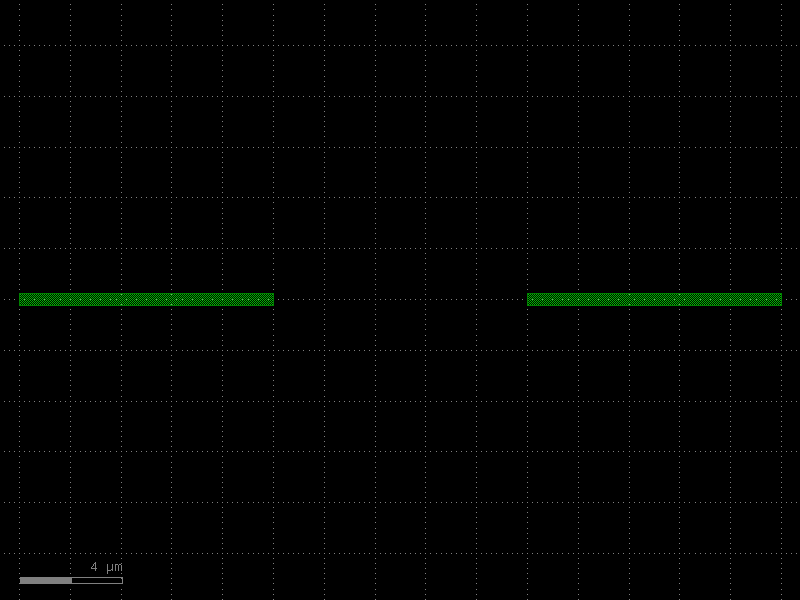

In [5]:
@pdk.schematic_cell
def two_straights() -> kf.Schematic:
    schematic = kf.Schematic(kcl=pdk)

    s1 = schematic.create_inst(
        name="s1",
        component="straight",
        settings={"width": 500, "length": 10_000},
    )
    s2 = schematic.create_inst(
        name="s2",
        component="straight",
        settings={"width": 500, "length": 10_000},
    )

    s1.place(x=0, y=0)
    s2.place(x=20_000, y=0)

    return schematic


cell = two_straights()
cell

The `@pdk.schematic_cell` decorator caches the result just like `@pdk.cell`, so calling
`two_straights()` a second time returns the same object.

## Connectivity: `connect`

`inst.connect(port_name, other_port)` aligns an instance so that the named port is
mated with `other_port`.  This is the schematic equivalent of the imperative
`instance.connect()` in a regular cell body.

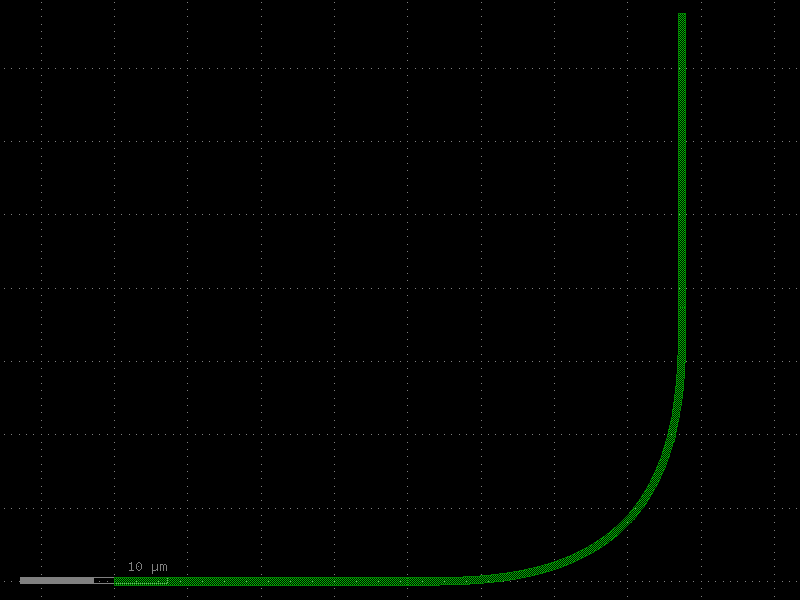

In [6]:
@pdk.schematic_cell
def chain_of_three() -> kf.Schematic:
    schematic = kf.Schematic(kcl=pdk)

    s1 = schematic.create_inst(
        name="s1",
        component="straight",
        settings={"width": 500, "length": 20_000},
    )
    b1 = schematic.create_inst(
        name="b1",
        component="bend90",
        settings={"width": 500, "radius": 10_000},
    )
    s2 = schematic.create_inst(
        name="s2",
        component="straight",
        settings={"width": 500, "length": 20_000},
    )

    # Fix s1 at the origin
    s1.place(x=0, y=0)

    # Snap b1's input port ("o1") onto s1's output port ("o2")
    b1.connect("o1", s1.ports["o2"])

    # Snap s2's input port ("o1") onto b1's output port ("o2")
    s2.connect("o1", b1.ports["o2"])

    return schematic


chain = chain_of_three()
chain

## The schematic model

The `schematic` attribute on a schematic cell contains the full declarative description
as a Pydantic model.  This includes instances, placements, nets, and routes.

In [7]:

model = chain.schematic
print("Instances:", list(model.instances.keys()))
print(
    "Placements:", {k: (v.x, v.y, v.orientation) for k, v in model.placements.items()}
)

Instances: ['s1', 'b1', 's2']
Placements: {'s1': (0, 0, 0.0)}


## Netlist extraction

`cell.netlist()` extracts a connectivity netlist from the physical layout.
Because each `SchematicInstance` places a real KCell into the layout, the extracted
netlist reflects the actual geometry — not just the schematic intent.

In [8]:
netlist = chain.netlist()
for cell_name, net in netlist.items():
    print(f"\n=== {cell_name} ===")
    print(f"  instances: {list(net.instances.keys())}")
    for i, n in enumerate(net.nets):
        print(
            f"  net[{i}]: "
            f"{[f'{p.instance}.{p.port}' if isinstance(p, PortRef) else f'<{p.name}>' for p in n]}"
        )
    print(f"  ports: {[p.name for p in net.ports]}")


=== chain_of_three ===
  instances: ['b1', 's1', 's2']
  net[0]: ['b1.o1', 's1.o2']
  net[1]: ['b1.o2', 's2.o1']
  net[2]: ['s1.o1']
  net[3]: ['s2.o2']
  ports: []

=== bend90_W500_R10000 ===
  instances: []
  net[0]: ['<o1>']
  net[1]: ['<o2>']
  ports: ['o1', 'o2']

=== straight_W500_L20000 ===
  instances: []
  net[0]: ['<o1>']
  net[1]: ['<o2>']
  ports: ['o1', 'o2']


## Schematic netlist vs extracted netlist (LVS)

For a schematic cell with declared nets (`schematic.nets`), kfactory can compare the
schematic connectivity against the extracted layout connectivity.  Here we use a version
with explicit nets to demonstrate the LVS flow.

In [9]:
@pdk.schematic_cell
def lvs_example() -> kf.Schematic:
    schematic = kf.Schematic(kcl=pdk)

    s1 = schematic.create_inst(
        name="s1",
        component="straight",
        settings={"width": 500, "length": 15_000},
    )
    s2 = schematic.create_inst(
        name="s2",
        component="straight",
        settings={"width": 500, "length": 15_000},
    )

    s1.place(x=0, y=0)

    # connect() both places s2 and records the connectivity in the schematic model
    s2.connect("o1", s1.ports["o2"])

    # Expose the two free ends as top-level ports.  Without this the extracted
    # netlist reports them as dangling single-port nets, which would not match
    # the declared schematic netlist during LVS.
    schematic.add_port("o1", port=s1.ports["o1"])
    schematic.add_port("o2", port=s2.ports["o2"])

    return schematic


lvs_cell = lvs_example()

# schematic.netlist() derives connectivity from the declared placements/connections
schematic_netlist = lvs_cell.schematic.netlist()

# cell.netlist() derives connectivity from the physical layout geometry
extracted_netlist = lvs_cell.netlist()[lvs_cell.name]

assert schematic_netlist == extracted_netlist, "LVS failed!"
print("LVS passed: schematic and extracted netlists match.")

LVS passed: schematic and extracted netlists match.


## Code generation

`schematic.code_str()` generates a standalone Python function that re-creates the same
layout without the schematic machinery.  This is useful for:

- Exporting a schematic-designed cell for use in a lower-level flow
- Archiving a point-in-time snapshot of a parameterised design
- Sharing a self-contained design with collaborators who do not use schematics

In [10]:
from IPython.display import Code

generated = chain.schematic.code_str()
Code(generated)

2026-07-15 15:42:40.191 | WARNING  | kfactory.schematic:code_str:2246 - Ruff not found or installed. Returning unformatted string.


import kfactory as kf


kcl = kf.kcls["SCHEM_OVERVIEW"]

@kcl.schematic_cell(output_type=kf.DKCell)
def chain_of_three() -> kf.Schematic:
  schematic = kf.Schematic(kcl=kcl)

  # Create the schematic instances
  b1 = schematic.create_inst(
    name='b1',
    component='bend90',
    settings={'width': 500, 'radius': 10000},
  )
  s1 = schematic.create_inst(
    name='s1',
    component='straight',
    settings={'width': 500, 'length': 20000},
  )
  s2 = schematic.create_inst(
    name='s2',
    component='straight',
    settings={'width': 500, 'length': 20000},
  )

  # Schematic instance placements
  s1.place(
  )

  # Schematic connections
  b1.connect(
    port='o1',
    other=s1['o2'],
  )
  b1.connect(
    port='o2',
    other=s2['o1'],
  )
  return schematic

The generated code is a regular `@kcl.schematic_cell`-decorated function — you can
copy it into any file that imports the same PDK and it will produce an identical cell.

## Summary

| Operation | API |
|-----------|-----|
| Define a schematic cell | `@pdk.schematic_cell` |
| Add a component instance | `schematic.create_inst(name, component, settings)` |
| Place at coordinate | `inst.place(x, y)` |
| Connect two ports | `inst.connect(port, other_port)` |
| Declare explicit net | `schematic.add_net(name, [port, ...])` |
| Extract layout netlist | `cell.netlist()` |
| Get schematic model | `cell.schematic` |
| Generate standalone code | `cell.schematic.code_str()` |

## See Also

| Topic | Where |
|-------|-------|
| Netlist data model | [Schematics: Netlist](netlist.py) |
| 45° crossing with virtual cells | [Schematics: 45° Crossing](crossing45.py) |
| Creating a full PDK | [PDK: Creating a PDK](../pdk/creating_pdk.py) |
| PCells & caching | [Components: PCells](../components/cells/pcells.py) |